In [1]:
import pygame
import os
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
from PIL import Image
import random
import matplotlib.pyplot as plt
from matplotlib import animation
from collections import deque

print(torch.cuda.is_available())  # 應該為 True
print(torch.version.cuda)         # 應該列出 CUDA 版本
print(torch.backends.cudnn.version())  # cuDNN 版本
script_dir = os.path.join(os.getcwd(), 'space_ship_game_RL')
if script_dir not in sys.path:
    sys.path.append(script_dir)

from setting import *
from game import Game
from tqdm import trange   # 進度列，非必要

pygame 2.6.1 (SDL 2.28.4, Python 3.12.11)
Hello from the pygame community. https://www.pygame.org/contribute.html
True
11.8
90100


In [2]:
class SpaceShipEnv():
    def __init__(self):
        pygame.init()
        pygame.font.init()

        # 延後畫面初始化，等 render() 時才設置
        self.screen = None
        self.clock = pygame.time.Clock()
        self.fps = FPS

        self.game = Game()

        self.prev_health = self.game.player.sprite.health
        self.prev_score = self.game.score

        self.action_space = [0, 1, 2, 3]
        self.observation  = self.game.state

    def step(self, action):
        self.game.update(action)

        if self.screen is None:
            self.game.draw()
        else:
            self.game.draw(self.screen)
            self.clock.tick(self.fps)

        # 1. 擊中石頭獎勵 ＝ 分數增量
        score_delta = self.game.score - self.prev_score
        hit_reward  = score_delta * 1.0           # 可視需要 *係數
        self.prev_score = self.game.score

        # 2. 受傷 / 回復
        damage = max(0, self.prev_health - self.game.player.sprite.health)
        heal   = max(0, self.game.player.sprite.health - self.prev_health)
        hp_reward = heal * 0.03 - damage * 0.10
        self.prev_health = self.game.player.sprite.health

        # 3. 存活微罰
        alive_penalty = -0.02

        reward = hit_reward + hp_reward + alive_penalty
        # ----------------------------------------

        done = (not self.game.running) or (self.game.score >= 10_000)
        info = {
            "score"   : self.game.score,
            "r_score" : hit_reward,      # ★ 用分數增量取代 r_score
            "r_hp"    : hp_reward
        }
        
        return self.game.state, reward, done, info

    def reset(self):
        self.game = Game()
        self.prev_health = self.game.player.sprite.health
        self.prev_score  = self.game.score 
        return self.game.state

    def render(self):
        if self.screen is None:
            self.screen = pygame.display.set_mode((WIDTH, HEIGHT))
            pygame.display.set_caption("SpaceShip RL Environment")

    def close(self):
        pygame.quit()

In [3]:
# Hyperparameters
num_episodes = 4000
batch_size = 64
gamma = 0.99
lr = 1e-4
epsilon_start = 1.0
epsilon_end = 0.5
epsilon_decay = 0.999
memory_capacity = 60000  # 100000
target_update_freq = 2000   # 1000

max_episode      = 2000          # 只先跑 1~2k 集
eval_interval    = 200           # 每 200 集評估一次
eval_episodes    = 5
warmup_steps     = 10_000        # buffer 重新塞滿多少步再開始學
epsilon_high     = 0.30          # reset 後暫時拉高
epsilon_low      = 0.05
epsilon_decay_ep = 1500          # 幾集內線性降至 epsilon_low
ma_window        = 100           # moving-average 視窗

In [4]:
# epsilon_list=[]
# epsilon = epsilon_high
# for i in range(max_episode):
#     epsilon = max(epsilon_low, epsilon * epsilon_decay)
#     epsilon_list.append(epsilon)
# plt.plot(epsilon_list)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# CNN-based DQN Model
class DQN(nn.Module):
    def __init__(self, num_actions):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(4, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [7]:
# Replay buffer
# 用於儲存代理人經驗（狀態、動作、獎勵等）的緩衝區，支援隨機抽樣以打破時間相關性，有助於穩定訓練。

class ReplayMemory:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
        # Use deque with a fixed capacity to automatically discard the oldest experience when full.
        # 使用 deque 並設定最大長度，當容量滿時會自動移除最舊的資料。

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        # Store a single transition (experience) in the buffer.
        # 儲存一筆經驗（狀態轉移）進緩衝區。

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        # Randomly sample a batch of transitions to break correlation between consecutive samples.
        # 隨機抽取一批經驗，打破樣本間的時間關聯性，提高訓練穩定性。

        # Unpack each element into separate tensors for network input
        # 將 batch 拆解成分別的 tensor 以供神經網路訓練
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # Convert the sampled data into tensors and move them to the specified device (CPU or GPU)
        # 將抽樣資料轉成 tensor 並移至指定設備（CPU/GPU）
        states = torch.tensor(np.stack(states), dtype=torch.float32, device=device)
        actions = torch.tensor(actions, dtype=torch.int64, device=device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
        next_states = torch.tensor(np.stack(next_states), dtype=torch.float32, device=device)
        dones = torch.tensor(dones, dtype=torch.float32, device=device)
        
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)
        # Return the current size of the buffer.
        # 回傳緩衝區目前儲存的資料數量。

In [8]:
# Preprocess frames (grayscale and resize to 84x84)
# 預處理影格：轉為灰階並縮放為 84x84

def preprocess_frame(frame):
    # frame 是 numpy array (H, W, 3)，先轉為 PIL Image
    # Input is a color image (RGB), convert to PIL format for easier processing.
    # 輸入是彩色圖像（RGB），轉成 PIL Image 以方便處理。
    image = Image.fromarray(frame)

    # 轉灰階
    # Convert the image to grayscale to reduce input complexity.
    # 將影像轉為灰階，降低輸入維度與計算量。
    image = image.convert('L')

    # resize 成 84x84
    # Resize the image to a standard 84x84 shape, as per DQN convention.
    # 依照 DQN 的慣例將影像統一縮放至 84x84。
    image = image.resize((84, 84), Image.Resampling.BILINEAR)  # or NEAREST, or LANCZOS

    # 轉回 numpy 並正規化
    # Convert back to NumPy and normalize pixel values to [0, 1].
    # 轉回 NumPy 格式並將像素值標準化到 [0, 1]。
    frame = np.asarray(image, dtype=np.float32) / 255.0

    return frame


def stack_frames(stacked_frames, state, is_new_episode):
    # 預處理目前影格
    frame = preprocess_frame(state)

    if is_new_episode or stacked_frames is None:
        # If it's a new episode or no previous frames, initialize with 4 identical frames
        # 若是新的一集或是尚未初始化，則用目前影格複製 4 次形成初始堆疊
        stacked_frames = deque([frame]*4, maxlen=4)
    else:
        # 否則把新影格加入到堆疊中，自動捨棄最舊的
        stacked_frames.append(frame)

    # Stack the 4 frames along the first dimension: shape becomes (4, 84, 84)
    # 沿著第一維（channel）堆疊成 4 通道輸入：形狀變成 (4, 84, 84)
    stacked_state = np.stack(stacked_frames, axis=0)

    return stacked_state, stacked_frames


In [9]:
# --------------------------------------------------
# 1. 環境與網路
env = SpaceShipEnv()
num_actions = len(env.action_space)

policy_net = DQN(num_actions).to(device)
target_net = DQN(num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=lr)

memory = ReplayMemory(memory_capacity)

# --------------------------------------------------
# 2. 載入舊權重 & **刷新 buffer、epsilon**
if os.path.exists('checkpoint.pth'):
    checkpoint = torch.load('checkpoint.pth', map_location=device)
    policy_net.load_state_dict(checkpoint['policy_net'])
    target_net.load_state_dict(checkpoint['target_net'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    start_episode = checkpoint['episode'] + 1
    total_steps = checkpoint['total_steps']
    best_score = checkpoint['best_score']
    epsilon = checkpoint['epsilon']
    reward_history = checkpoint['reward_history']
    score_history = checkpoint['score_history']
    # r_score_hist = checkpoint['r_score_hist']
    # r_hp_hist = checkpoint['r_hp_hist']
    print(f"Loaded checkpoint from episode {start_episode}, best score: {best_score:.2f}, epsilon={epsilon:.3f}")
    
else:
    start_episode, total_steps, best_score = 0, 0, float('-inf')
    epsilon = epsilon_start
    reward_history = []
    score_history = []

##### <<< 新增：重置探索率 & 清空記憶 >>> #####
epsilon = epsilon_high
memory = ReplayMemory(memory_capacity)


# --------------------------------------------------
# 3. 紀錄用資料結構
reward_history, score_history = [], []
r_score_hist, r_hp_hist         = [], []          # 原始
ma_hit,    ma_hp              = [], []          # moving-average

def moving_average(data, k):
    if len(data) < k: return np.mean(data) if data else 0.0
    return np.mean(data[-k:])

# --------------------------------------------------
# 4. 評估函式（固定 ε=0，不回寫經驗）
@torch.no_grad()
def evaluate_policy():
    scores = []
    for _ in range(eval_episodes):
        s = env.reset()
        s, _stack = stack_frames(None, s, True)
        done = False
        while not done:
            at = policy_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))\
                     .argmax(dim=1).item()
            s_next, _, done, info = env.step(at)
            s_next, _stack = stack_frames(_stack, s_next, False)
            s = s_next
        scores.append(info["score"])
    print(f"[EVAL] avg_score={np.mean(scores):.1f}, best={np.max(scores):.1f}")

# 訓練迴圈 / Training loop
# 每次可以訓練個100步(根據自己的設備與時間調整)，然後下一次都再接續上次的訓練模型接續往下訓練
# You can train for 100 steps each time (adjust according to your own equipment and time), 
# and then continue training from the last training model next time.

# --------------------------------------------------
# 5. 訓練迴圈
for episode in trange(start_episode, start_episode + max_episode, desc="Training"):
    state = env.reset()
    state, stacked_frames = stack_frames(None, state, True)
    done, total_reward = False, 0

    while not done:
        # ε-greedy
        if random.random() < epsilon:
            action = random.choice(env.action_space)
        else:
            with torch.no_grad():
                at = policy_net(torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0))
                action = at.argmax(dim=1).item()

        # 執行並取得 info
        next_state, reward, done_, info = env.step(action)
        done = done_
        total_reward += reward

        # 存 replay
        next_state, stacked_frames = stack_frames(stacked_frames, next_state, False)
        memory.push(state, action, reward, next_state, done)
        state = next_state

        # ====== 梯度更新 ======
        if len(memory) >= batch_size and total_steps > warmup_steps:
            states, actions, rewards, next_states, dones = memory.sample(batch_size)
            with torch.no_grad():
                target_q = rewards + gamma * target_net(next_states).max(1)[0] * (1 - dones)
            current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
            loss = F.mse_loss(current_q, target_q)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 5)  # 避免爆梯
            optimizer.step()

        # ====== 更新 target net ======
        total_steps += 1
        if total_steps % target_update_freq == 0:
            target_net.load_state_dict(policy_net.state_dict())

        # ====== 收集統計 ======
        r_score_hist.append(info["r_score"])
        r_hp_hist .append(info["r_hp"])

    # ------- episode 結束 -------
    score = info["score"]
    reward_history.append(total_reward)
    score_history .append(score)
    ma_hit.append(moving_average(r_score_hist, ma_window))
    ma_hp .append(moving_average(r_hp_hist , ma_window))

    # 線性衰減 ε
    progress = min(1.0, episode / epsilon_decay_ep)
    epsilon = epsilon_low + (epsilon_high - epsilon_low) * (1 - progress)

    # 簡易 log
    print(f"Ep {episode:4d} | Reward={total_reward:7.2f} | Score={score:4d} | ε={epsilon:.3f} "
          f"| ma_hit={ma_hit[-1]:5.2f} ma_hp={ma_hp[-1]:5.2f}")

    # ----- 定期評估 -----
    if (episode + 1) % eval_interval == 0:
        evaluate_policy()
    # 儲存模型（若比目前最佳分數更好，或每 50 回合）
    if (episode + 1) % 50 == 0 or score > best_score:
        best_score = max(best_score, score)

        torch.save({
            'policy_net': policy_net.state_dict(),
            'target_net': target_net.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epsilon': epsilon,
            'episode': episode,
            'total_steps': total_steps,
            'best_score': best_score,
            'reward_history': reward_history,
            'score_history': score_history,
            'r_score_hist' : r_score_hist,
            'r_hp_hist' : r_hp_hist
        }, 'checkpoint.pth')

        print(f"Checkpoint saved at episode {episode + 1}, best score: {best_score:.2f}")

env.close()


Loaded checkpoint from episode 4000, best score: 1264.00, epsilon=0.018


Training:   0%|          | 1/2000 [00:05<3:01:12,  5.44s/it]

Ep 4000 | Reward= 135.20 | Score= 152 | ε=0.050 | ma_hit= 0.60 ma_hp=-0.04


Training:   0%|          | 2/2000 [00:13<3:59:05,  7.18s/it]

Ep 4001 | Reward=  58.34 | Score=  78 | ε=0.050 | ma_hit= 0.52 ma_hp=-0.04


...

Ep 4074 | Reward= 319.90 | Score= 352 | ε=0.050 | ma_hit= 0.52 ma_hp=-0.03


Training:   4%|▍         | 76/2000 [15:52<9:10:31, 17.17s/it]

Ep 4075 | Reward= 508.98 | Score= 536 | ε=0.050 | ma_hit= 0.92 ma_hp=-0.03


Training:   4%|▍         | 76/2000 [16:21<6:54:20, 12.92s/it]


KeyboardInterrupt: 

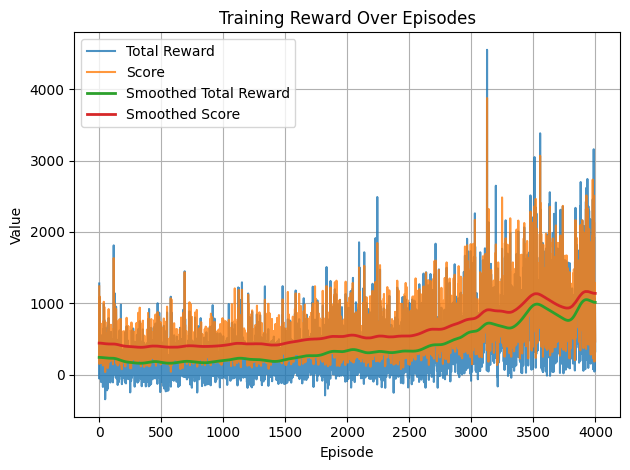

In [ ]:
from scipy.ndimage import gaussian_filter1d

reward_smooth = gaussian_filter1d(reward_history, sigma=50)
score_smooth = gaussian_filter1d(score_history, sigma=50)

# 畫圖
# plt.figure(figsize=(10, 5))
plt.plot(reward_history, label='Total Reward', alpha=0.8)
plt.plot(score_history, label='Score', alpha=0.8)
plt.plot(reward_smooth, label='Smoothed Total Reward', linewidth=2)
plt.plot(score_smooth, label='Smoothed Score', linewidth=2)

plt.legend(loc='upper left')
plt.xlabel("Episode")
plt.ylabel("Value")
plt.title("Training Reward Over Episodes")
plt.grid(True)
plt.tight_layout()
# plt.savefig("dqn_training_curve.png")

